# Examen Modulo 1

${\huge\textbf{Iranian Churn}}$

* Centeno Amado Eduardo
* Orozpe Frias Erick Adrian
* Pineda Gaona Maricruz
* Rodríguez Teodores Armando Jair
* Velasco Martell Dayra

# Instrucciones

![act1](act1T04.png)
![act2](act2T04.png)

# Bibliotecas

In [ ]:
# Instalar la primera vez de ejecución
# pip install pyod

In [1]:
#General
import pandas as pd
import numpy as np
import re #RegEx

#Graficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#Valores atipicos
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.mcd import MCD

#Reduccion de dimension
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.manifold import TSNE

#Escaladores
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

#Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

#Pruebas estadisticas
from scipy.stats import kruskal, chi2_contingency

#Codificadores
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# 1. Extracción de Datos

Descarga el dataset de UCI en el siguiente link:
https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset

Explora el sitio para tener informaci ́on de las variables y sus consideraciones.

In [2]:
df = pd.read_csv(r"https://raw.githubusercontent.com/armandoteo/Datos-CDD/refs/heads/main/Customer%20Churn.csv")

In [4]:
print("Dimensión", df.shape)

Dimensión (3150, 14)


*Este conjunto de datos fue recolectado aleatoriamente de la base de datos de una compañía de telecomunicaciones iraní durante un periodo de 12 meses. Consta de un total de 3,150 registros, cada uno representando a un cliente, con información en 13 columnas.*

| Variable Name           | Role    | Type       | Description                                                       |
| ----------------------- | ------- | ---------- | ----------------------------------------------------------------- |
| Call Failure            | Feature | Integer    | Número de llamadas fallidas                                       |
| Complains               | Feature | Binary     | Quejas del cliente (0 = No, 1 = Sí)                               |
| Subscription Length     | Feature | Integer    | Meses totales de suscripción                                      |
| Charge Amount           | Feature | Integer    | Monto de cargos (0 = más bajo, 9 = más alto)                      |
| Seconds of Use          | Feature | Integer    | Total de segundos en llamadas                                     |
| Frequency of use        | Feature | Integer    | Número total de llamadas realizadas                               |
| Frequency of SMS        | Feature | Integer    | Número total de mensajes SMS enviados                             |
| Distinct Called Numbers | Feature | Integer    | Cantidad de números de teléfono distintos llamados                |
| Age Group               | Feature | Integer    | Grupo de edad (1 = más joven, 5 = mayor)                          |
| Tariff Plan             | Feature | Integer    | Plan de tarifa (1 = prepago, 2 = contrato)                        |
| Status                  | Feature | Binary     | Estado del cliente (1 = activo, 2 = inactivo)                     |
| Age                     | Feature | Integer    | Edad exacta del cliente                                           |
| Customer Value          | Feature | Continuous | Valor calculado del cliente                                       |
| Churn                   | Target  | Binary     | Variable objetivo: 1 = Churn (abandono), 0 = No Churn (retención) |




*Los atributos incluidos en este conjunto de datos son: fallas en llamadas, frecuencia de SMS, número de quejas, número de llamadas distintas, duración de la suscripción, grupo de edad, monto de cargos, tipo de servicio, segundos de uso, estado, frecuencia de uso y valor del cliente.*

*Todos los atributos, excepto la variable churn, corresponden a datos agregados de los primeros 9 meses. Las etiquetas de churn reflejan el estado de los clientes al finalizar los 12 meses. Los tres meses restantes representan el periodo definido como brecha de planeación. Data Set Recolectado de:
https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset*

# 2. Valores Ausentes

In [5]:
def is_na_df(df):
    #Establecemos el resumen de NAs por columna
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    #Tomamos totales y prporciones
    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    #Filtramos solo columnas con al menos 1 NA
    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    #Agregamos fila resumen global
    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    resumen = pd.DataFrame({
        "columna": ["TOTAL"],
        "n_missing": [total_missing],
        "total": [total_elements],
        "prop_missing": [prop_missing_global],
        "prop_original": [prop_original_global]
    })

    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

In [6]:
is_na_df(df)

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,44100,0.0,1.0


La base no trae valores ausentes como se comenta en el sitio web de donde se extrajo el dataset.

# 3. Análisis Exploratorio

${\large\text{Describe la distribución de la variable objetivo (Churn). ¿Está balanceada?}}$

In [ ]:
conteo = df['Churn'].value_counts()
display(pd.concat([df['Churn'].value_counts(), df['Churn'].value_counts(normalize=True).apply(lambda x: '{:.2%}'.format(x))], axis=1))

balance_ratio = conteo.min() / conteo.max()

print(f"\nÍndice de balance de {balance_ratio:.2%}", end=" por lo que ")

if balance_ratio > 0.7:
    print("la variable está relativamente balanceada.")
elif balance_ratio > 0.3:
    print("hay cierto desbalance, podría afectar algunos modelos.")
else:
    print("hay fuerte desbalance.")

,count,proportion
Churn,,
0,2655,84.29%
1,495,15.71%



Índice de balance de 18.64% por lo que hay fuerte desbalance.


*La distribución de la variable objetivo refleja que el 84.29% de los clientes permanecieron con la compañía, mientras que el 15.71% abandonaron el servicio. Esto evidencia un desbalance en la variable de churn, dado que la mayoría de los registros corresponden a clientes retenidos frente a una menor proporción de clientes en fuga.*

${\large\text{Calcula estadísticas descriptivas para variables numéricas. ¿Qué puedes inferir sobre ellas? ¿Hay valores atípicos?}}$

In [122]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#008080"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#00a77d", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values, textinfo='percent+label')]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self, color, values: bool = False):
        corr_matrix = self.df[self.num_vars].corr()

        if values:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color,
                text=corr_matrix.round(1).values,      # valores de correlación con 1 decimal
                texttemplate="%{text}",                # mostrar texto en cada celda
                textfont={"size":10, "color":"black"}  # estilo de fuente
                ))
        else:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color
                ))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [18]:
# Definimos las variables categoricas
var_cat = ['Complains','Charge  Amount','Age Group','Tariff Plan','Status','Churn']

# Definimos las variables numericas
var_num = list(set(df.columns) - set(var_cat))

In [123]:
analisis = analyze(df, var_num, var_cat)

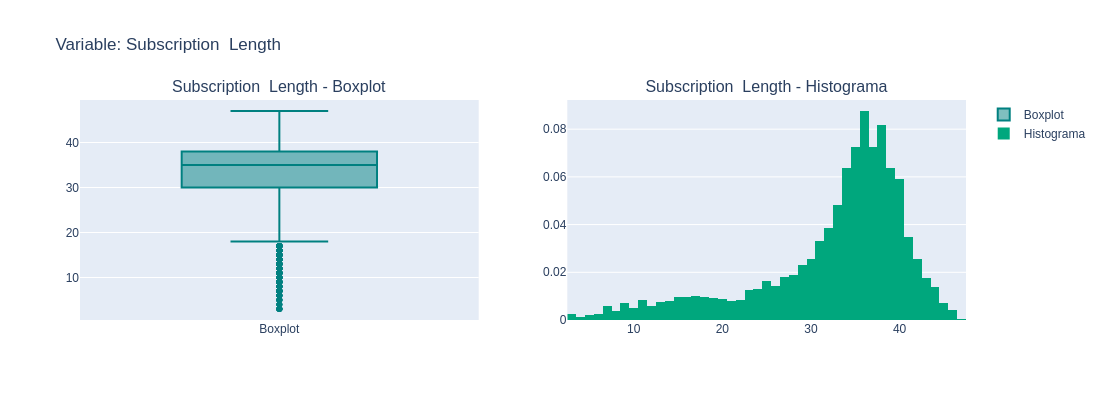

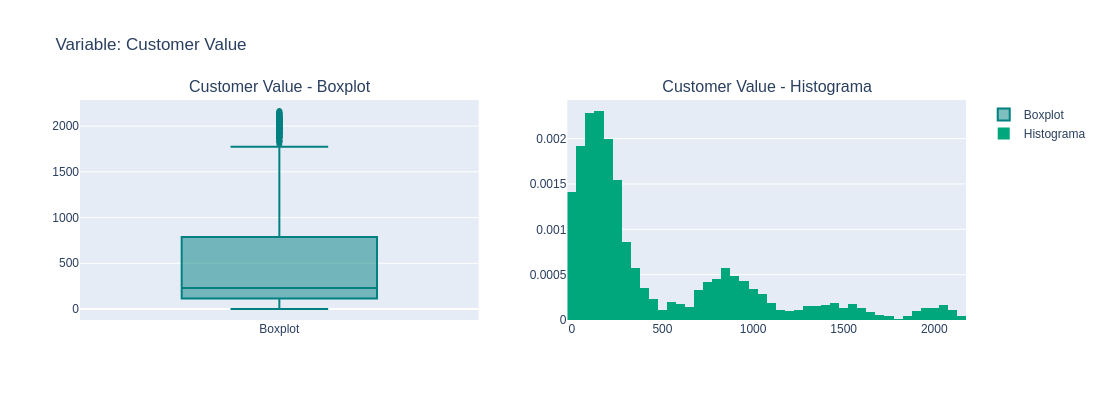

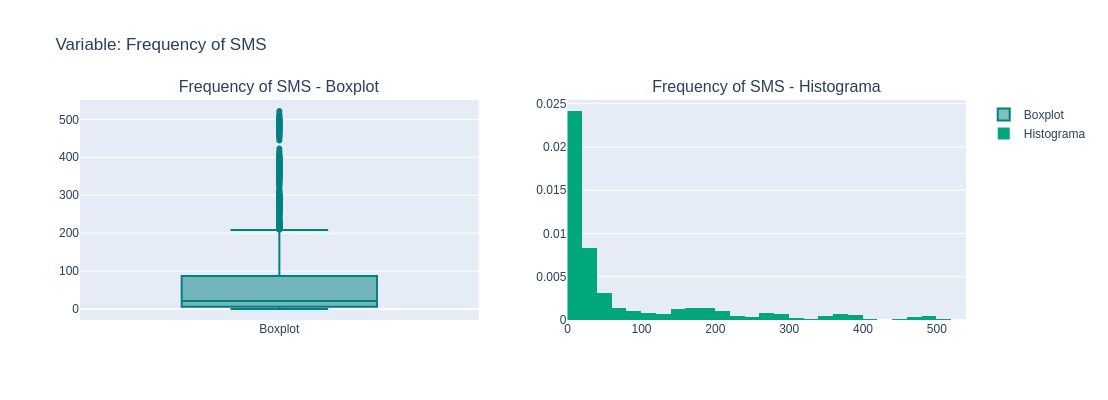

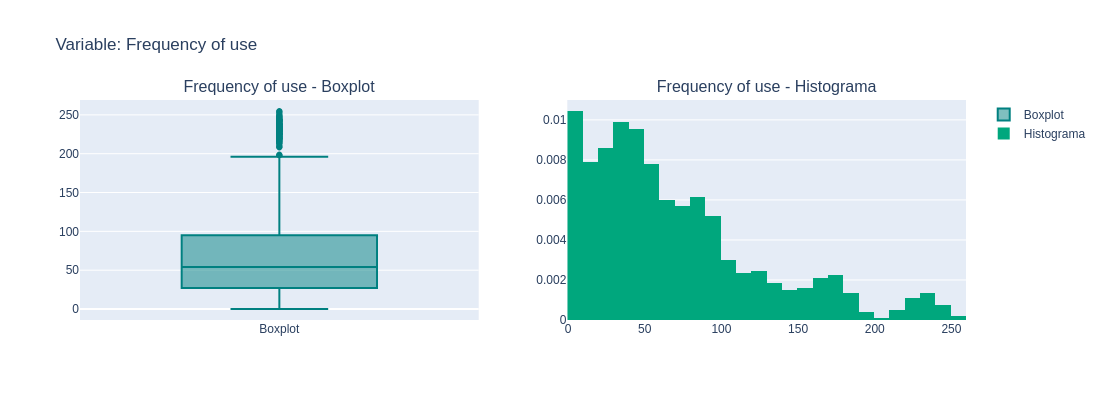

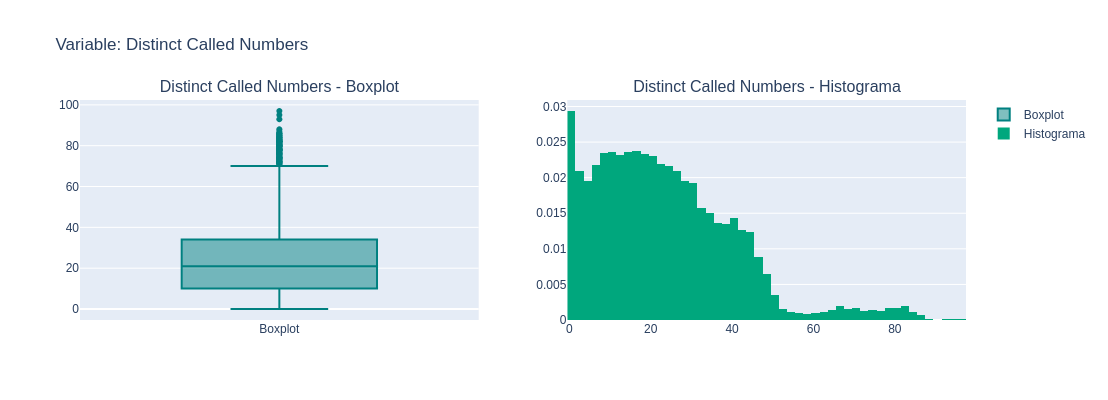

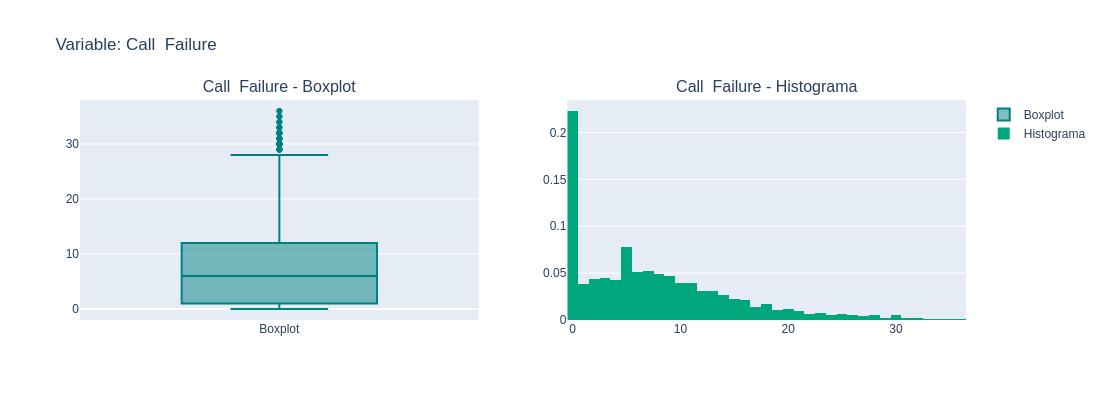

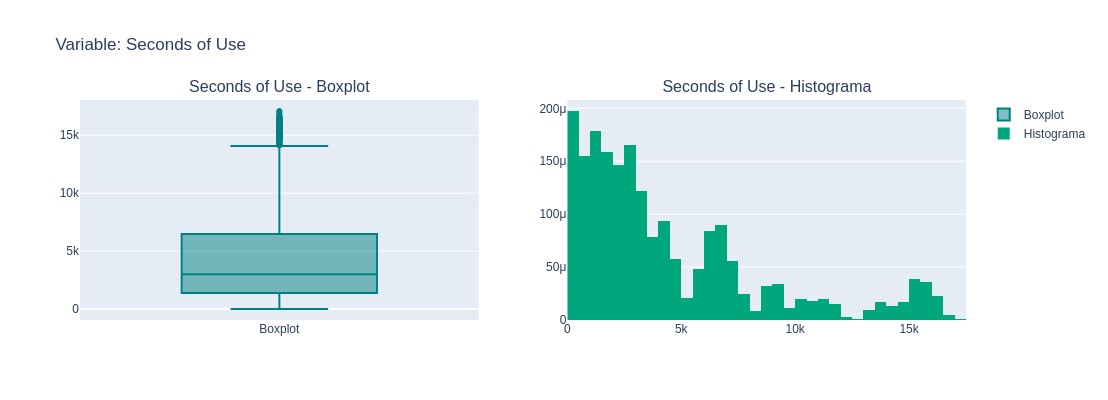

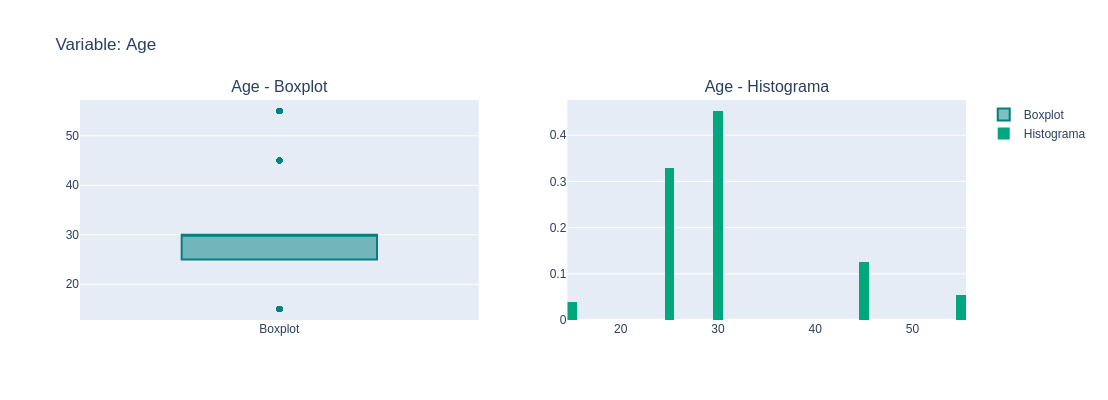

In [45]:
analisis.plot_num()

In [145]:
perc=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]

In [146]:
# Vemos las estadísticas
df[var_num].describe(percentiles=perc).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Subscription Length,3150.0,32.541905,8.573482,3.0,7.0,13.000,30.00000,35.00,38.00000,42.00,45.0000,47.00
Customer Value,3150.0,470.972916,517.015433,0.0,0.0,10.335,113.80125,228.48,788.38875,1587.68,2059.9036,2165.28
Frequency of SMS,3150.0,73.174921,112.237560,0.0,0.0,0.000,6.00000,21.00,87.00000,356.55,483.0000,522.00
Frequency of use,3150.0,69.460635,57.413308,0.0,0.0,1.000,27.00000,54.00,95.00000,184.55,238.5100,255.00
Distinct Called Numbers,3150.0,23.509841,17.217337,0.0,0.0,1.000,10.00000,21.00,34.00000,51.00,80.0000,97.00
Call Failure,3150.0,7.627937,7.263886,0.0,0.0,0.000,1.00000,6.00,12.00000,22.00,30.0000,36.00
Seconds of Use,3150.0,4472.459683,4197.908687,0.0,0.0,54.500,1391.25000,2990.00,6478.25000,15020.50,16127.6500,17090.00
Age,3150.0,30.998413,8.831095,15.0,15.0,25.000,25.00000,30.00,30.00000,55.00,55.0000,55.00


In [50]:
# Intervalo de edades por Age Group
df.groupby('Age Group')['Age'].agg(['count','min','mean','median','max'])

,count,min,mean,median,max
Age Group,,,,,
1,123,15,15.0,15.0,15
2,1037,25,25.0,25.0,25
3,1425,30,30.0,30.0,30
4,395,45,45.0,45.0,45
5,170,55,55.0,55.0,55


In [118]:
# Clasificación de la variable objetivo por Tipo de plan
aux = df.loc[:, ['Churn', 'Tariff Plan', 'Age']]
aux['Churn_recat'] = aux['Churn'].apply(lambda x: 'Abandono' if x == 1 else 'Retención')
aux['Tariff Plan_recat'] = aux['Tariff Plan'].apply(lambda x: 'Prepago' if x == 1 else 'Contractual')
aux.groupby(['Churn_recat', 'Tariff Plan_recat']).agg('count').iloc[:,0].reset_index(name='Count')

,Churn_recat,Tariff Plan_recat,Count
0,Abandono,Contractual,6
1,Abandono,Prepago,489
2,Retención,Contractual,239
3,Retención,Prepago,2416


*Puede no aportarnos para predecir si el cliente abandona por la alta concentración de prepago en los planes de tarifa.*

In [119]:
# Clasificación de la variable objetivo por Estatus del Cliente
aux = df.loc[:, ['Churn', 'Status', 'Age']]
aux['Churn_recat'] = aux['Churn'].apply(lambda x: 'Abandono' if x == 1 else 'Retención')
aux['Status_recat'] = aux['Status'].apply(lambda x: 'Activo' if x == 1 else 'Inactivo')
aux.groupby(['Churn_recat', 'Status_recat']).agg('count').iloc[:,0].reset_index(name='Count')

,Churn_recat,Status_recat,Count
0,Abandono,Activo,125
1,Abandono,Inactivo,370
2,Retención,Activo,2243
3,Retención,Inactivo,412


*Puede aportarnos para predecir si el cliente abandona por que tenemos distribución de clientes activos e inactivos, además vemos cierta relación de abandono por clientes inactivos lo cual hace sentido.*

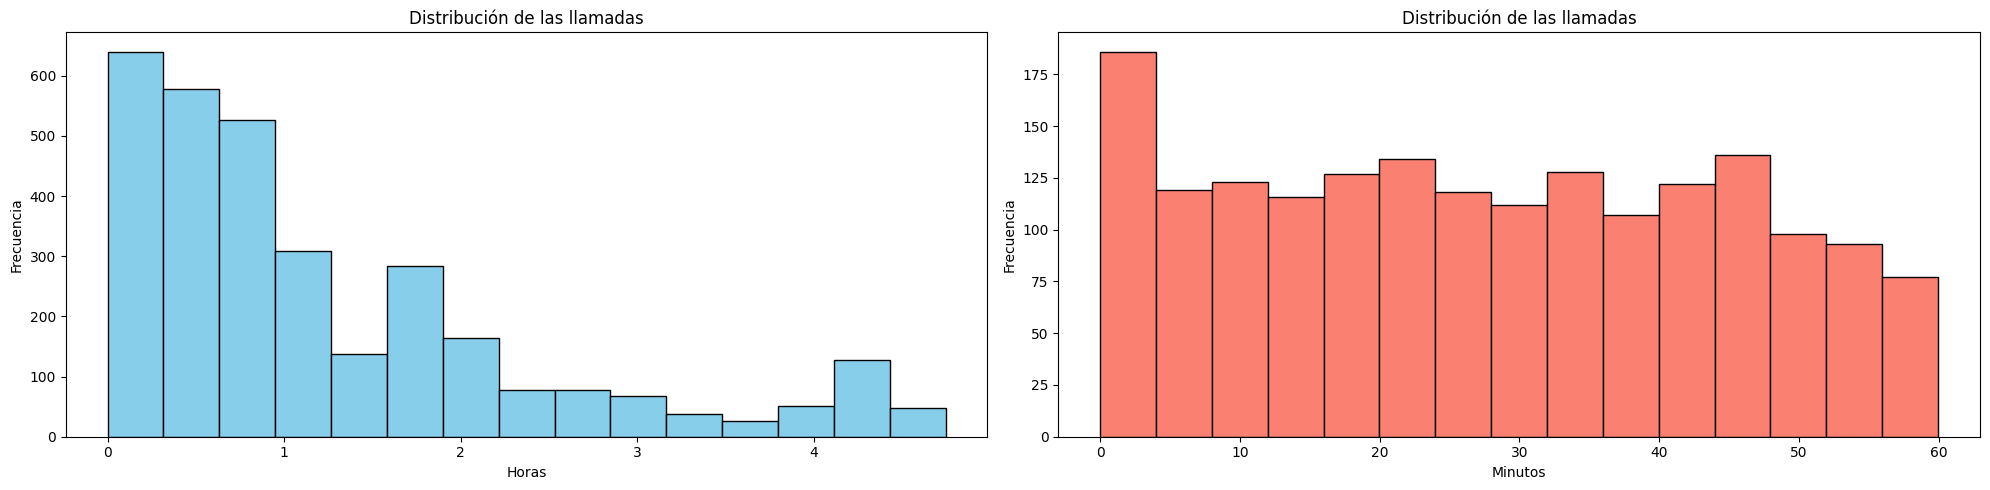

In [80]:
# Crear figura con dos ejes (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Histograma en el primer eje
axes[0].hist(df['Seconds of Use']/3600, bins=15, color="skyblue", edgecolor="black")
axes[0].set_title("Distribución de las llamadas")
axes[0].set_xlabel("Horas")
axes[0].set_ylabel("Frecuencia")

# Histograma en el segundo eje
axes[1].hist(df.loc[:,['Seconds of Use']].apply(lambda x: x/60).query("`Seconds of Use` <= 60"), bins=15, color="salmon", edgecolor="black")
axes[1].set_title("Distribución de las llamadas")
axes[1].set_xlabel("Minutos")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [100]:
# H0: El número de llamadas realizadas es igual a la cantidad de números distintos marcados por el cliente

aux2 = (df['Frequency of use'] == df['Distinct Called Numbers'])

display(
    (
        pd.concat(
            [aux2.value_counts(), aux2.value_counts(normalize=True).apply(lambda x: '{:.2%}'.format(x))], 
            axis=1
        )
    )
)

,count,proportion
False,2976,94.48%
True,174,5.52%


${\large\text{Call Failure}}$

El rango intercuantil está entre 1 y 12 llamadas con falla, pero algunos casos extremos elevan el promedio.  

---

${\large\text{Subscription Length}}$

El rango intercuantil está entre 30 y 38 meses (aprox. 2 a 3 años), lo cual está acorde con la media y mediana, es decir, hablamos de una duración de suscripción estable en el conjunto e inclinado a la derecha con respecto al valor mínimo (cero).

---

${\large\text{Age}}$

Variable categoríca ya que en el histograma se ve como un gráfico de barras de frecuencia en lugar de una distribución.  

---

${\large\text{Seconds of Use}}$

La cola está inclinada a la izquierda cuando vemos la distribución de uso en horas y adicional a este punto, al graficar la distribución en minutos de llamadas con duración de 1 hora vemos una distribución prácticamente uniforme, sin embargo, los clientes con un uso elevado incrementa la cantidad de outliers.

---

${\large\text{Frequency of SMS}}$

La mitad de los clientes manda menos de 21 SMS, sin embargo, vemos que se comienza a disparar los valores a 87 en el tercer cuantil y hasta un valor máximo de 522 SMS, lo cual nos habla de una variable con al menos una cuarta parte compuesta de valores atípicos.

---

${\large\text{Frequency of Use}}$

* Una cuarta parte de los clientes realiza menos de 21 llamadas
* El rango intercuantil se encuentra entre 21 y 95 llamadas; y
* El resto de clientes eleva el promedio de la variable, teniendo un valor máximo de 255 llamadas realizadas.

---
 
${\large\text{Distinct Called Numbers}}$

El 95% de los clientes repite al menos una llamada al mismo número. Mientras que la frecuencia de uso se encuentra entre 21 y 95 llamadas, la cantidad de números distintos que marca el cliente se encuentra entre 10 y 34 lo cual confirma el enunciado, se repiten llamadas a un mismo número.

---

${\large\text{Customer Value}}$

El costo de las llamadas que realizan los clientes se encuentra entre 113 y 788, sin embargo, la mediana está en 228 lo que nos habla de valores elevados ya que la media se encuentra en 500.

*De los gráficos observados, los histogramas y gráficos de caja podríamos inferir que en efecto hay valores atípicos ya que en más de una variable observamos alta concentración en un intervalo de valores, sin embargo, necesitamos entender la naturaleza de nuestros datos para determinar si son atípicos o no.*

${\large\text{Analiza las variables categóricas. Considera normalizarlas si lo crees necesario.}}$

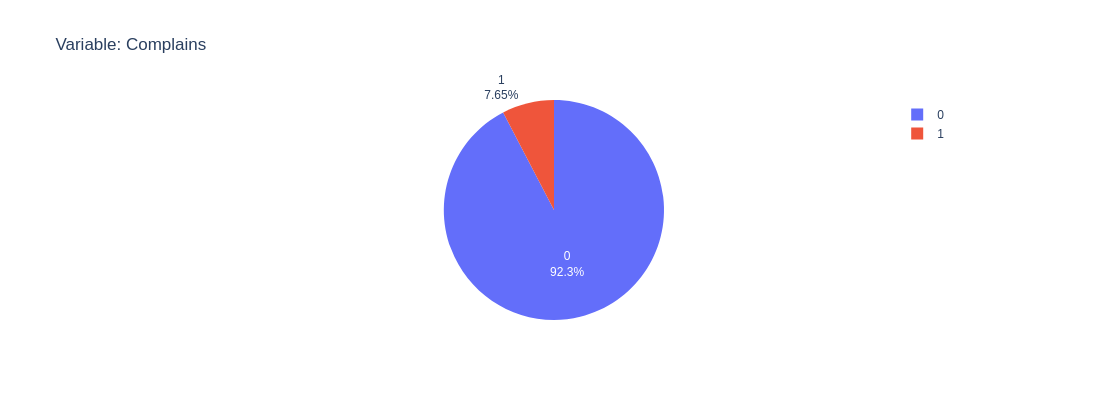

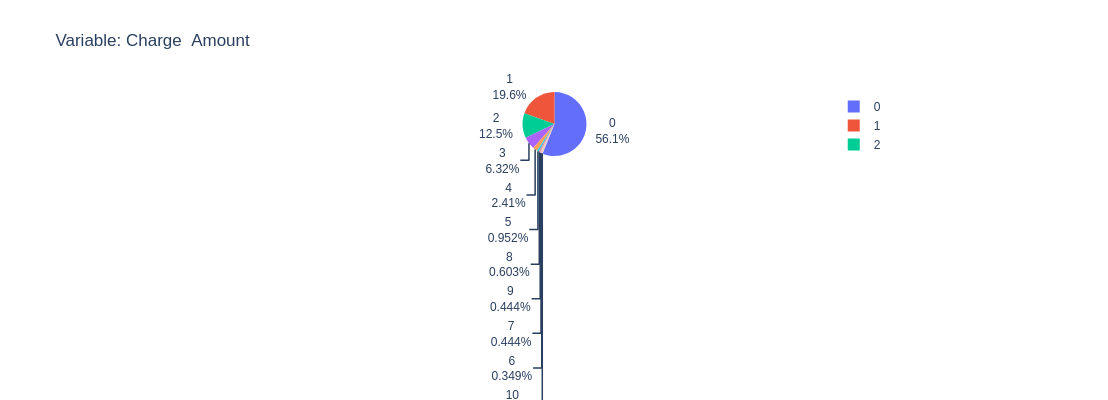

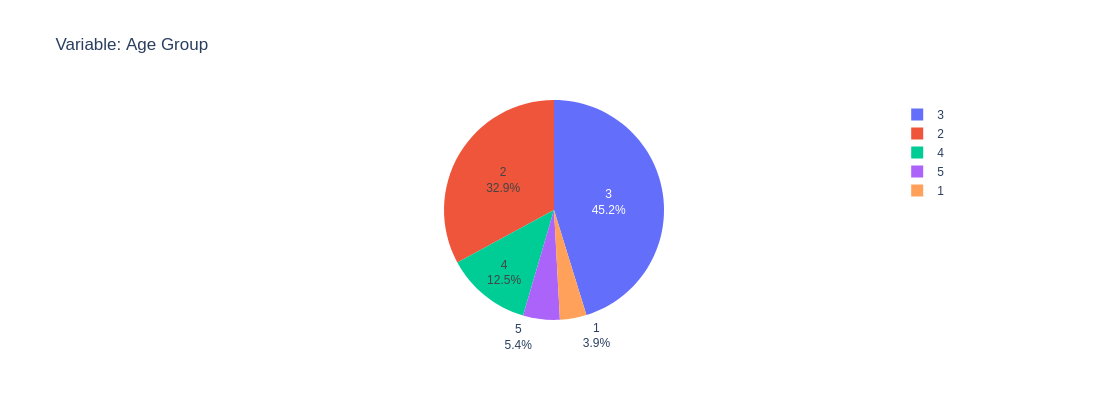

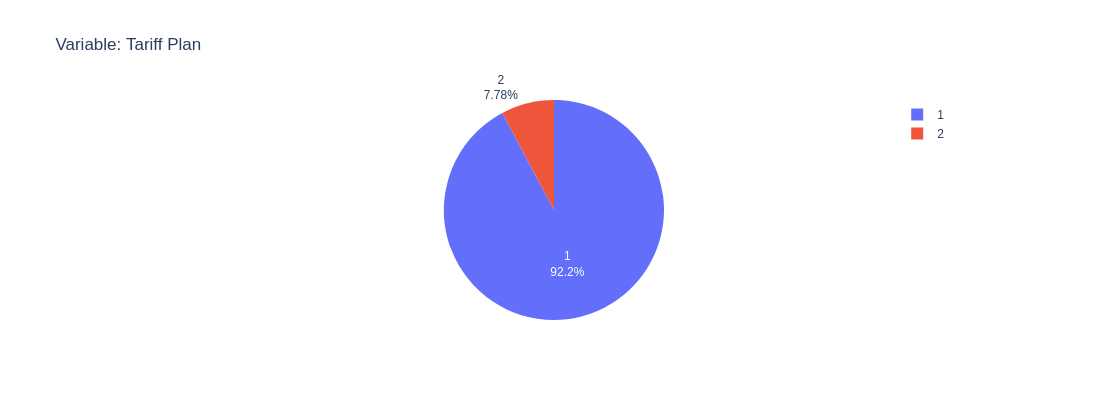

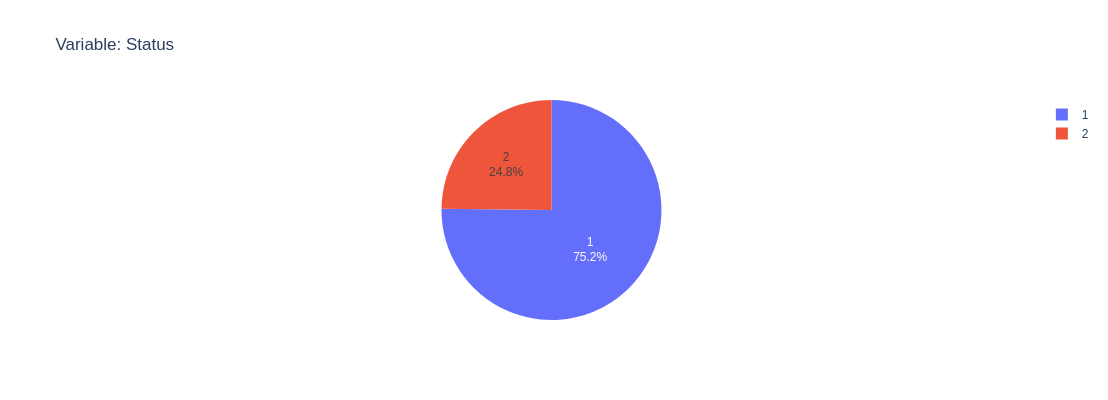

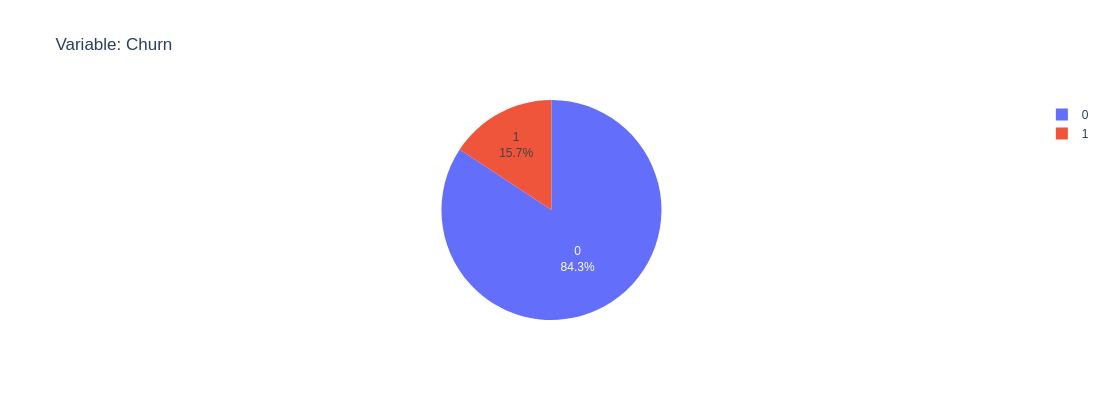

In [46]:
analisis.plot_cat()

${\large\text{Complains}}$

Alta concentración en el valor cero por lo que puede no aportar al modelo incluirla.

---

${\large\text{Charge Amount}}$

Alta cantidad de categorías, quizás convenga recategorizar esta variable.

---

${\large\text{Age Group}}$

Alta concentración en los valores 2 y 3 por lo que quizás convenga recategorizar esta variable. Además, observamos que cada categoría representa un número de edad, no un intervalo de edades por lo que podríamos pensar que ya es una columna categórica de la variable edad.

---

${\large\text{Tariff Plan}}$

Alta concentración en el valor 1 (prepago) por lo que puede no aportar al modelo.

---

${\large\text{Status}}$

Se encuentra con mejor distribución de ambos valores encontrados 1 (activo) y 2 (inactivo).


In [113]:
# Clasificación de la variable objetivo por si el cliente marcó para una queja o no
aux = df.loc[:, ['Churn', 'Complains', 'Age']]
aux['Churn_recat'] = aux['Churn'].apply(lambda x: 'Abandono' if x == 1 else 'Retención')
aux['Complains_recat'] = aux['Complains'].apply(lambda x: 'Queja' if x == 1 else 'Sin Queja')
aux.groupby(['Churn_recat', 'Complains_recat']).agg('count').iloc[:, 0].reset_index(name='Count')

,Churn_recat,Complains_recat,Count
0,Abandono,Queja,200
1,Abandono,Sin Queja,295
2,Retención,Queja,41
3,Retención,Sin Queja,2614


*Sí, vamos a normalizar Age Group y Charge Amount después de recategorizar la variable, así como Status y Tariff Plan.*

${\large\text{Remueve valores atípicos si lo consideras pertinente. Justifica el porqué.}}$

*Por los histogramas y gráficos de caja podríamos pensar que hay outliers debido a que en algunas variables tenemos alta concentración de valores en un rango y el resto puedan estar muy por encima o por debajo de ese rango intercuantil, sin embargo, por la naturaleza del dataset no observamos algo fuera de lo común como que un cliente haya realizado menos una llamada o haya tenido menos una llamada fallida, por lo que consideramos que el dataset no tiene valores atípicos; quizás, sí podemos decir que algunas variables no guardan una distribución uniforme. Además cada cliente tiene un grado distinto de necesidad de realizar una llamada y eso hace que tengamos estos outliers.*

${\large\text{Explora correlaciones entre las variables numéricas. ¿Tienen sentido estas correlaciones? ¿Existen problemas de multicolinealidad?}}$

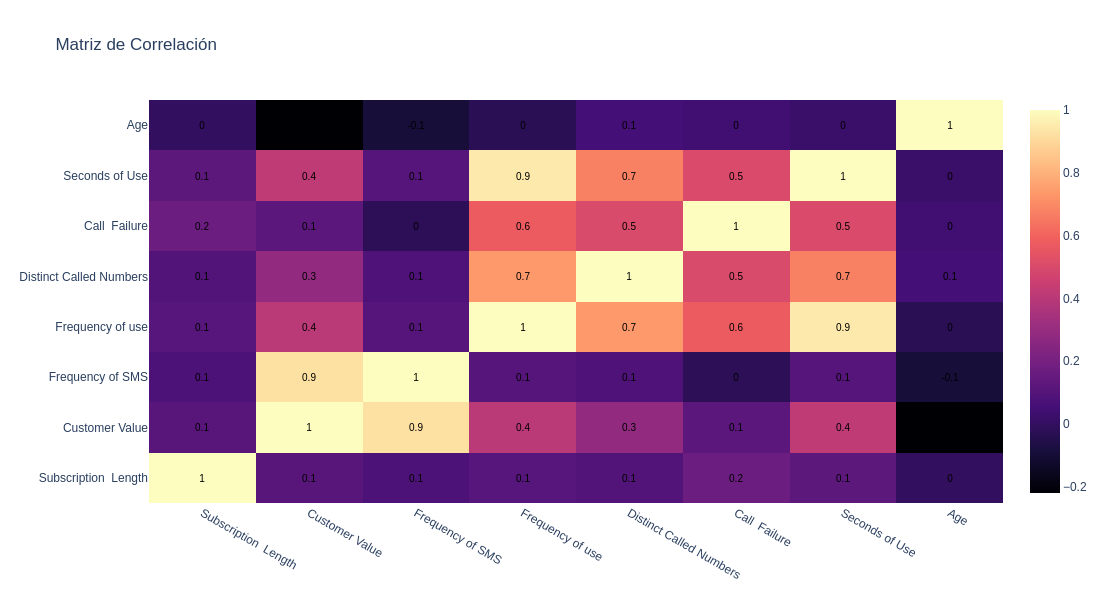

In [125]:
analisis.corr_matrix('magma', values=True)

*Si observamos una correlación positiva entre algunas de las variables y hacen perfecto sentido*
* *Tiempo de uso (en segundos) y frecuencia de uso (0.9)*
* *Costo del cliente y la cantidad de SMS enviados (0.9)*
* *Cantidad de números distintos marcados y la frecuencia de uso (0.7)*
* *Cantidad de llamadas fallidas y frecuencia de uso (0.6)*
* *Costo del clientes y la frecuencia de uso (0.4)*

*Sí pudiera haber problemas de multicolinealidad ya que vemos la mitad de las variables correlacionadas positivamente, las que menos se relacionan con las otras variables son: duración de suscripción, costo del cliente, frecuencia de sms enviados y la edad.*

${\large\text{Identifica variables que parecen influir más en Churn.}}$

In [216]:
def stats_churn(churn: int): print(f'Churn = {churn}') ; display(df.query(f'Churn == {churn}').loc[:, var_num].describe(percentiles=perc).T)

stats_churn(0)
stats_churn(1)

Churn = 0


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Subscription Length,2655.0,32.662524,8.392357,3.0,8.0,15.0000,29.000,35.00,38.0000,42.0000,45.000,47.00
Customer Value,2655.0,535.511501,536.214629,0.0,0.0,26.9265,142.065,268.07,864.5475,1662.8745,2071.575,2165.28
Frequency of SMS,2655.0,83.871563,118.808594,0.0,0.0,0.0000,7.000,25.00,133.0000,367.0000,485.000,522.00
Frequency of use,2655.0,76.979284,58.499847,0.0,0.0,6.0000,32.000,63.00,104.0000,192.3000,241.000,255.00
Distinct Called Numbers,2655.0,25.582674,17.389349,0.0,0.0,2.0000,12.000,23.00,36.0000,58.0000,81.460,97.00
Call Failure,2655.0,7.656121,7.154318,0.0,0.0,0.0000,1.000,6.00,12.0000,22.0000,30.000,36.00
Seconds of Use,2655.0,5014.224105,4312.742630,0.0,0.0,395.0000,1819.000,3530.00,6892.5000,15221.5000,16192.300,17090.00
Age,2655.0,31.065913,9.147610,15.0,15.0,25.0000,25.000,30.00,30.0000,55.0000,55.000,55.00


Churn = 1


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Subscription Length,495.0,31.894949,9.469163,3.0,4.0,8.0,31.000,35.00,37.0000,41.000,43.0600,45.000
Customer Value,495.0,124.811414,129.429850,0.0,0.0,0.0,38.375,96.84,181.3225,335.235,509.4366,987.255
Frequency of SMS,495.0,15.802020,23.515289,0.0,0.0,0.0,0.000,9.00,23.0000,48.000,79.7800,204.000
Frequency of use,495.0,29.133333,26.323478,0.0,0.0,0.0,6.000,25.00,45.5000,91.300,98.0000,100.000
Distinct Called Numbers,495.0,12.391919,10.867622,0.0,0.0,0.0,2.000,10.00,20.0000,33.000,37.0600,48.000
Call Failure,495.0,7.476768,7.831407,0.0,0.0,0.0,0.000,5.00,11.0000,24.300,30.0000,34.000
Seconds of Use,495.0,1566.632323,1539.203365,0.0,0.0,0.0,318.000,1182.00,2391.5000,5513.000,5865.1000,6123.000
Age,495.0,30.636364,6.886081,25.0,25.0,25.0,25.000,30.00,30.0000,45.000,45.0000,55.000


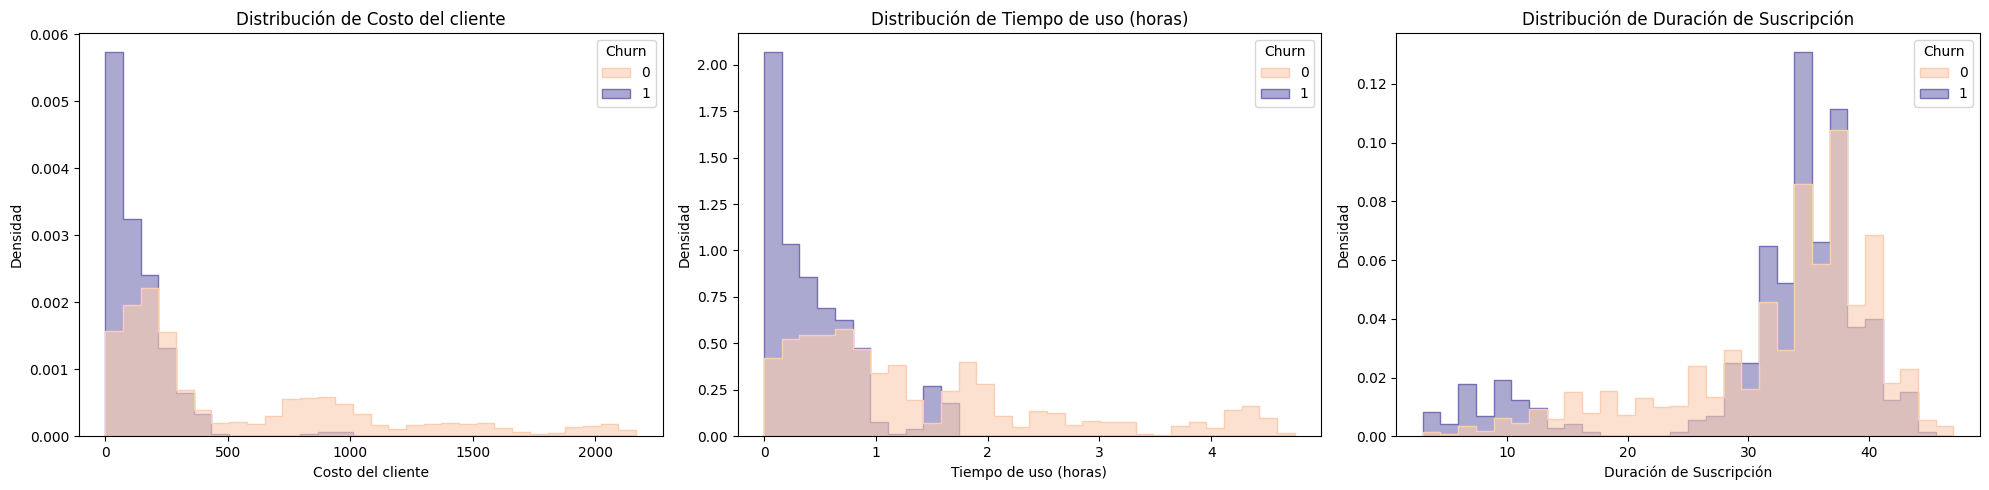

In [211]:
pal = {0: "#FBCEB1", 1: "#7570b3"}  # paleta de colores para la variable objetivo

def dist_plot(ax, serie: pd.Series, xlabel: str) -> None:
    sns.histplot(
        data=df,
        x=serie,
        hue="Churn",
        hue_order=[0, 1],
        palette=pal,
        bins=30,
        element='step',
        stat='density',
        multiple="layer",
        common_norm=False,
        alpha=0.6,
        ax=ax
    )
    ax.set_title(f'Distribución de {xlabel}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Densidad')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

dist_plot(axes[0], df['Customer Value'], 'Costo del cliente')
dist_plot(axes[1], df["Seconds of Use"]/3600, 'Tiempo de uso (horas)')
dist_plot(axes[2], df["Subscription  Length"], 'Duración de Suscripción')

plt.tight_layout(); plt.show()

*Vemos una posible relación entre el tiempo de uso y la variable objetivo, así como el costo del cliente.*

Decidimos normalizar la variable **Charge Amount** dado que se vemos que la categorías de 7 a 10 están demasiado pulverizadas por lo cual procedemos a clasificarla de [0,2] en bajo, [3,5] en medio y [6,10] en alto